SALES PREDICTION USING PYTHON

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Load Dataset

In [2]:
df = pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


Dataset Information

In [3]:
print("Dataset Shape :", df.shape)
df.info()

Dataset Shape : (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


Check Missing Values

In [4]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Visualization

Advertising Budget Distribution

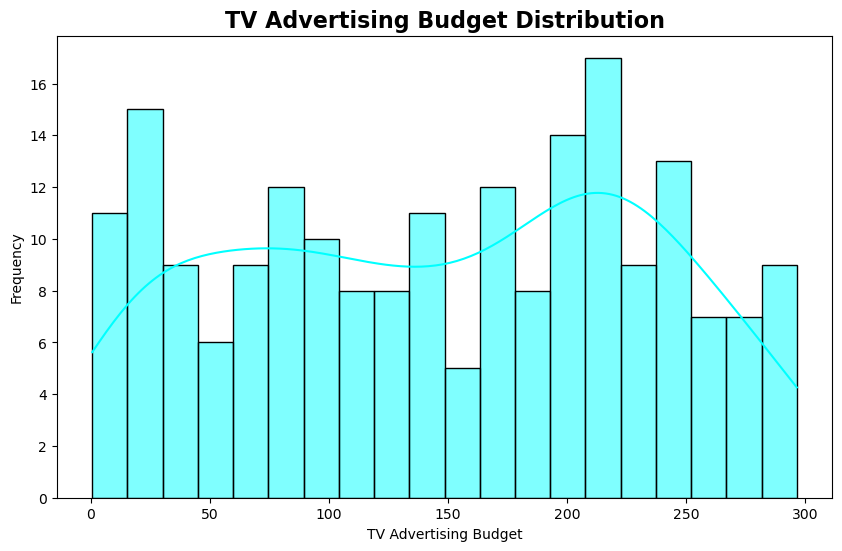

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['TV'],
    bins=20,
    color='cyan',
    kde=True
)

plt.title("TV Advertising Budget Distribution",
          fontsize=16,
          fontweight='bold')

plt.xlabel("TV Advertising Budget")
plt.ylabel("Frequency")

plt.show()

TV Advertising vs Sales

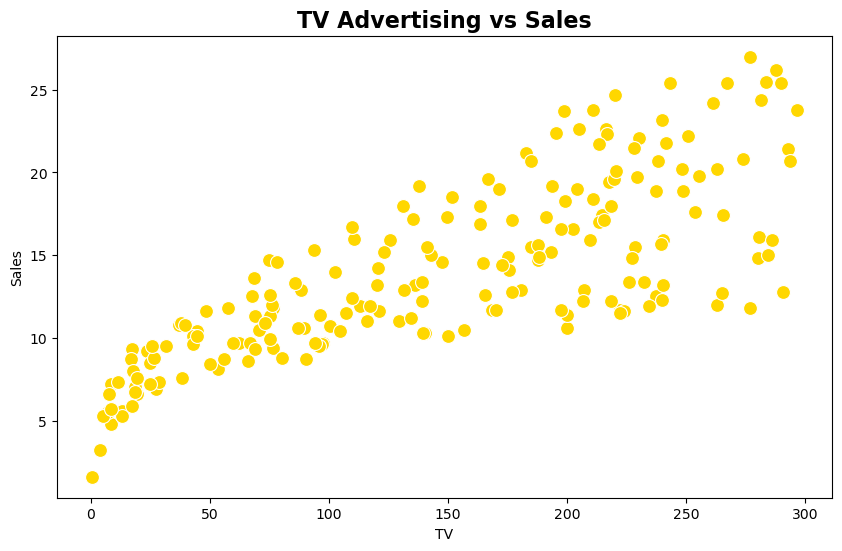

In [6]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='TV',
    y='Sales',
    color='gold',
    s=100
)

plt.title("TV Advertising vs Sales",
          fontsize=16,
          fontweight='bold')

plt.show()

Correlation Heatmap

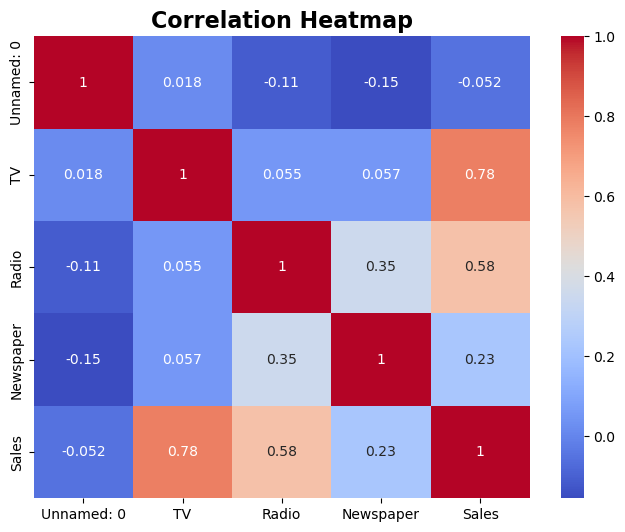

In [7]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap",
          fontsize=16,
          fontweight='bold')

plt.show()

Feature Selection

In [8]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Prediction

In [11]:
y_pred = model.predict(X_test)

Model Evaluation

In [12]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,2))

MAE : 1.46
RMSE : 1.78
R2 Score : 0.9


Actual vs Predicted Sales

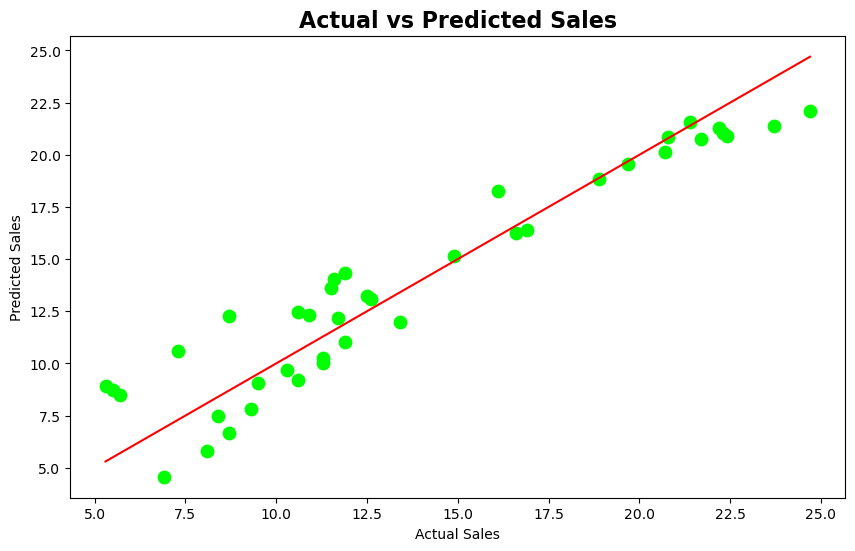

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred,
    color='lime',
    s=80
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.title("Actual vs Predicted Sales",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.show()

Predict Future Sales

In [14]:
new_data = pd.DataFrame({
    'TV':[230],
    'Radio':[37],
    'Newspaper':[69]
})

prediction = model.predict(new_data)

print("Predicted Sales :",
      round(prediction[0],2))

Predicted Sales : 20.46


Feature Importance

In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(importance)

     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761
